# Week 22: Audit transfer before calling it a foundation model

Does source training improve target dynamics after matching labels, representation and optimizer budget?

**Prerequisites:** Week 7.4 already introduces diverse pretraining. This capstone audits mechanisms and claims rather than repeating that introduction.

Allow 120 minutes plus the written analysis. Instructor solution edition.

In [1]:
from pathlib import Path
import sys, tempfile, json
ROOT=next((p for p in [Path.cwd(),*Path.cwd().parents] if (p/'flowmllab/transformer_course.py').exists()),None)
if ROOT is None:
    raise RuntimeError('Extract the supplied course bundle and start Jupyter in its root; see docs/TRANSFORMER_COURSE.md for Colab upload setup.')
sys.path.insert(0,str(ROOT))
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from IPython.display import display
from flowmllab import transformer_course as lab
lab.seed_all(17)
cases,input_manifest=lab.load_data(ROOT)
EVIDENCE=ROOT/'results/transformer_course_v3'
# Any optional experiment must write into this disposable workspace.
workspace=tempfile.TemporaryDirectory(prefix='flowmllab-student-')
RUN_OUTPUT=Path(workspace.name)
task_status={}
print('Loaded checksummed simulated wake fields. No retained files will be rewritten.')

task_status={i:None for i in range(1,5)}


Loaded checksummed simulated wake fields. No retained files will be rewritten.


In [2]:
RUN_EXERCISES=True

## Count every target label and fix the forecast start

Inspect every neural arm at step zero. Scratch, matched-steps and target-POD-MLP are freshly initialized when their selected step is zero; pretrained step zero means no target adaptation after source fitting. Source validation uses a 50-step rollout and target validation six-step blocks. All three retained source fits selected step 300/300, so source checkpoint selection did not alter the final source weights in these runs. Different window coverage, validation horizons and budgets prevent a single-factor causal attribution of transfer gain.

In [3]:
for blocks in (4,8,15):
    train,val,labels=lab.transfer_indices(blocks)
    print(blocks,'blocks:',len(labels['training_frames']),'training +',len(labels['validation_frames']),'validation +',len(labels['initialization_frames']),'initialization =',labels['total_target_labels'])
record=json.loads((EVIDENCE/'transfer.json').read_text())
rows=record['rows'];display(pd.DataFrame([{'Re':r['target_re'],'labels':r['labels']['total_target_labels'],'arm':r['arm'],'seed':r['seed'],'field':r['metrics']['field_relative_l2'],'floor':r['metrics']['representation_floor'],'subspace':r['metrics']['in_subspace_relative_l2'],'steps':r.get('total_optimizer_steps'),'selected_step':(r.get('training') or {}).get('selected_step'),'boundary':(r.get('training') or {}).get('at_budget_boundary'),'no_target_adaptation':r['arm']=='pretrained' and r.get('training',{}).get('selected_step')==0,'control_untrained':r['arm'] in ('scratch','matched-steps','target-POD-MLP') and (r.get('training') or {}).get('selected_step')==0} for r in rows]))

4 blocks: 30 training + 10 validation + 4 initialization = 44
8 blocks: 60 training + 20 validation + 4 initialization = 84
15 blocks: 120 training + 30 validation + 4 initialization = 154


,Re,labels,arm,seed,field,floor,subspace,steps,selected_step,boundary,no_target_adaptation,control_untrained
0,100,44,scratch,17,0.963946,0.147758,0.952554,300.0,0.0,False,False,True
1,100,44,pretrained,17,0.408994,0.147758,0.381370,600.0,0.0,False,True,False
2,100,44,matched-steps,17,0.963946,0.147758,0.952554,600.0,0.0,False,False,True
3,100,44,target-POD-MLP,17,0.973617,0.538693,0.811011,300.0,0.0,False,False,True
4,100,44,DMD,17,1.151185,0.147758,1.141663,NaN,NaN,None,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...
130,110,154,scratch,43,0.292207,0.255874,0.141115,300.0,300.0,True,False,False
131,110,154,pretrained,43,0.256380,0.255874,0.016088,600.0,300.0,True,False,False
132,110,154,matched-steps,43,0.257375,0.255874,0.027754,600.0,600.0,True,False,False
133,110,154,target-POD-MLP,43,0.056555,0.054003,0.016798,300.0,300.0,True,False,False


## Recompute transfer metrics from stored predictions

Source-POD arms isolate initialization of dynamics. The target-POD MLP is a representation control, not the same architecture. Matched steps are reported alongside measured fit seconds; steps are not FLOPs. Source pretraining is reused and its amortization depends on the number of deployments.

Recomputed W22 transfer metric: 0.6183241604274966


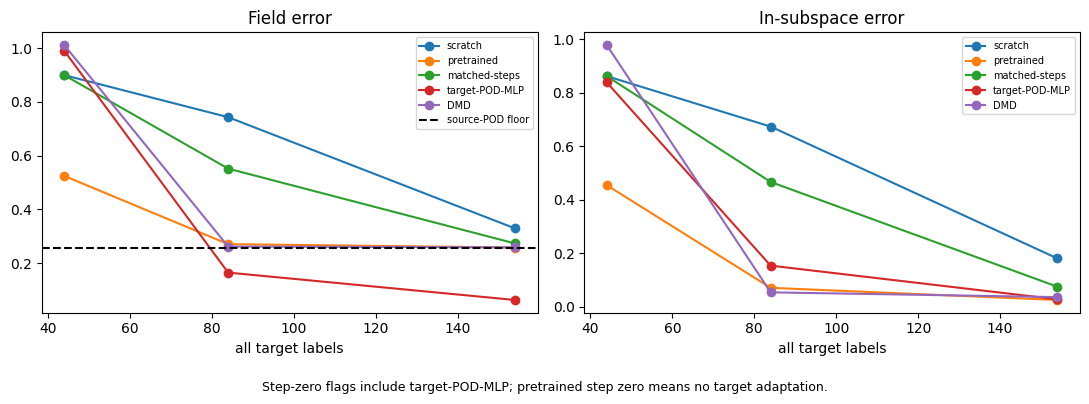

In [4]:
retained=np.load(EVIDENCE/'predictions.npz',allow_pickle=False)
row=next(r for r in rows if r['arm']=='pretrained' and r['target_re']==110)
pred=lab.prediction(retained,'transfer__'+row['key'])[50:]
truth=cases[110]['omega'][210:].reshape(71,-1)
score=np.linalg.norm(np.asarray(pred,dtype=np.float64)-np.asarray(truth,dtype=np.float64))/np.linalg.norm(np.asarray(truth,dtype=np.float64))
assert np.isclose(score,row['metrics']['field_relative_l2'],rtol=1e-6,atol=1e-9)
print('Recomputed W22 transfer metric:',score)
fig,axes=plt.subplots(1,2,figsize=(11,4))
for arm in ('scratch','pretrained','matched-steps','target-POD-MLP','DMD'):
    subset=[r for r in rows if r['arm']==arm and r['target_re']==110]
    for j,key in enumerate(('field_relative_l2','in_subspace_relative_l2')):
        groups={n:[r['metrics'][key] for r in subset if r['labels']['total_target_labels']==n] for n in (44,84,154)}
        axes[j].plot(list(groups),[np.mean(v) for v in groups.values()],marker='o',label=arm)
floor=next(r['metrics']['representation_floor'] for r in rows if r['target_re']==110 and r['arm']=='pretrained')
axes[0].axhline(floor,color='black',linestyle='--',label='source-POD floor')
for ax,title in zip(axes,['Field error','In-subspace error']):ax.set_title(title);ax.set_xlabel('all target labels');ax.legend(fontsize=7)
fig.text(.5,.01,'Step-zero flags include target-POD-MLP; pretrained step zero means no target adaptation.',ha='center',fontsize=9)
fig.tight_layout(rect=(0,.06,1,1));plt.show()

## Task 1: Audit information budgets

Return the cardinality of the union of all target frames used before scoring.

Interface contract: record has training_frames, validation_frames and initialization_frames, each an iterable of integer frame IDs. Return an integer cardinality of their union, counting every overlap once.

In [5]:
def label_count(record):
    return len(set(record["training_frames"])|set(record["validation_frames"])|set(record["initialization_frames"]))

In [6]:
if RUN_EXERCISES:
    try:
        for blocks in (4,8,15):assert label_count(lab.transfer_indices(blocks)[2])==blocks*10+4
        assert label_count({'training_frames':[1,2],'validation_frames':[2,3],'initialization_frames':[3,4]})==4
        task_status[1]=True
    except NotImplementedError:
        task_status[1]=None
    except Exception as exc:
        task_status[1]=False
        print("Task 1 check failed:",type(exc).__name__,str(exc))
else:
    task_status[1]=None
print("Task 1:","PASS" if task_status[1] is True else "NOT SUBMITTED" if task_status[1] is None else "FAILED")

Task 1: PASS


## Task 2: Match compute accounting

Count source pretraining and target adaptation steps for each learned arm, without charging source cost to a source-free arm.

Interface contract: adaptation is a dictionary with executed_steps (nonnegative integer). pretraining is None or a dictionary with executed_steps. Return their sum when pretraining is supplied, otherwise adaptation executed_steps.

In [7]:
def total_steps(adapt,pretrain=None):
    return adapt["executed_steps"]+(pretrain["executed_steps"] if pretrain else 0)

In [8]:
if RUN_EXERCISES:
    try:
        for adapt,source in ((3,7),(23,0),(0,11)):
            assert total_steps({'executed_steps':adapt},{'executed_steps':source})==adapt+source
        assert total_steps({'executed_steps':13})==13
        task_status[2]=True
    except NotImplementedError:
        task_status[2]=None
    except Exception as exc:
        task_status[2]=False
        print("Task 2 check failed:",type(exc).__name__,str(exc))
else:
    task_status[2]=None
print("Task 2:","PASS" if task_status[2] is True else "NOT SUBMITTED" if task_status[2] is None else "FAILED")

Task 2: PASS


## Task 3: Detect a representation-limited result

Flag cases where the squared representation error explains more than 95% of squared field error. Do not subtract unsquared norms.

Interface contract: metrics is a dictionary with representation_floor (floor) and field_relative_l2 (field), both nonnegative scalar relative L2 errors. Return a bool for floor**2/max(field**2,1e-20)>0.95. At zero/zero return False; use a strict threshold.

In [9]:
def representation_limited(metrics):
    return metrics["representation_floor"]**2/max(metrics["field_relative_l2"]**2,1e-20)>.95

In [10]:
if RUN_EXERCISES:
    try:
        assert representation_limited({'representation_floor':.2559,'field_relative_l2':.256})
        assert not representation_limited({'representation_floor':.1,'field_relative_l2':.5})
        assert not representation_limited({'representation_floor':0.,'field_relative_l2':0.})
        assert not representation_limited({'representation_floor':.20,'field_relative_l2':.21})
        assert representation_limited({'representation_floor':.21,'field_relative_l2':.21})
        task_status[3]=True
    except NotImplementedError:
        task_status[3]=None
    except Exception as exc:
        task_status[3]=False
        print("Task 3 check failed:",type(exc).__name__,str(exc))
else:
    task_status[3]=None
print("Task 3:","PASS" if task_status[3] is True else "NOT SUBMITTED" if task_status[3] is None else "FAILED")

Task 3: PASS


## Task 4: Build a defensible transfer comparison

For records with key (target, labels, seed), pair pretrained and matched-steps arms. Reject missing or duplicate arms and nonpositive control error. Return signed relative gain, selected-step flags and budget-boundary flags. Treat step-zero scratch/matched results as untrained controls. Apply the audit to a normalized copy of the retained table; explain why this does not isolate representation or validation-horizon effects.

Interface contract: Each input dictionary has target, labels (integer total target labels), seed, arm, error (in-subspace relative L2), selected_step, ceiling. Pair pretrained with matched-steps per (target,labels,seed), rejecting duplicates/missing arms or nonpositive control error with ValueError. Return a list sorted by group key of dictionaries: key (tuple), gain (1-pretrained_error/control_error), control_untrained (control selected step==0), pretrained_selected_step, control_selected_step, pretrained_boundary and control_boundary (each arm selected step==its own ceiling). Keep negative gains.

In [11]:
def audit_transfer_comparisons(records):
    groups={}
    for row in records:
        key=(row['target'],row['labels'],row['seed'])
        arms=groups.setdefault(key,{})
        if row['arm'] in arms:raise ValueError('duplicate arm')
        arms[row['arm']]=row
    results=[]
    for key,arms in sorted(groups.items()):
        if not {'pretrained','matched-steps'}<=set(arms):
            raise ValueError('missing matched comparison')
        pretrained=arms['pretrained']
        control=arms['matched-steps']
        if control['error']<=0:raise ValueError('nonpositive control error')
        results.append({'key':key,'gain':1-pretrained['error']/control['error'],
            'control_untrained':control['selected_step']==0,
            'pretrained_selected_step':pretrained['selected_step'],
            'control_selected_step':control['selected_step'],
            'pretrained_boundary':pretrained['selected_step']==pretrained['ceiling'],
            'control_boundary':control['selected_step']==control['ceiling']})
    return results

In [12]:
if RUN_EXERCISES:
    try:
        records=[]
        for target,pre,control,selected in ((100,.02,.01,0),(110,.01,.02,8)):
            for arm,error in [('pretrained',pre),('matched-steps',control)]:
                records.append({'target':target,'labels':44,'seed':17,'arm':arm,'error':error,'selected_step':selected,'ceiling':8})
        r=audit_transfer_comparisons(records)
        assert [v['gain'] for v in r]==[-1.,.5]
        assert r[0]['control_untrained'] and not r[1]['control_untrained']
        assert r[1]['control_boundary'] and not r[0]['control_boundary']
        for invalid in (records[:-1],records+[records[0]]):
            try:
                audit_transfer_comparisons(invalid)
                raise AssertionError('invalid pairing accepted')
            except ValueError:pass
        records=[{'target':105,'labels':84,'seed':29,'arm':'pretrained','error':.03,'selected_step':7,'ceiling':7},
                 {'target':105,'labels':84,'seed':29,'arm':'matched-steps','error':.04,'selected_step':2,'ceiling':11}]
        r=audit_transfer_comparisons(records)[0]
        assert r['pretrained_selected_step']==7 and r['control_selected_step']==2
        assert r['pretrained_boundary'] is True and r['control_boundary'] is False
        assert r['control_untrained'] is False and np.isclose(r['gain'],.25)
        records[0]['selected_step']=0;records[1]['selected_step']=11
        r=audit_transfer_comparisons(records)[0]
        assert r['pretrained_boundary'] is False and r['control_boundary'] is True
        assert r['control_untrained'] is False
        for invalid in (0.,-.1):
            records[1]['error']=invalid
            try:
                audit_transfer_comparisons(records)
                raise AssertionError('nonpositive control error accepted')
            except ValueError:pass
        task_status[4]=True
    except NotImplementedError:
        task_status[4]=None
    except Exception as exc:
        task_status[4]=False
        print("Task 4 check failed:",type(exc).__name__,str(exc))
else:
    task_status[4]=None
print("Task 4:","PASS" if task_status[4] is True else "NOT SUBMITTED" if task_status[4] is None else "FAILED")

Task 4: PASS


## Interpretation and submission

Submit the four completed functions, the requested plots/tables, and a 300-word claim ledger. Distinguish observations, fitted quantities, independent evaluation and unsupported extrapolation. Retain failed seeds. Use the lecture source for the rubric and assumptions.

In [13]:
print("Coding tasks passed:",sum(v is True for v in task_status.values()),"/",len(task_status))
assert all(v is True for v in task_status.values())
workspace.cleanup()

Coding tasks passed: 4 / 4
